In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Import necessary libraries # Code Snippet #1
import pandas as pd
import os

# List all files in the working directory (if already uploaded to Colab)
print("Files in the working directory:")
files = os.listdir()
print(files)

# Dictionary to map specific file names to descriptive dataset names
file_mapping = {
    "children-and-youth-demographics-by-age-group.csv": "demographics_age_group",
    "children-and-youth-demographics-by-race-group.csv": "demographics_race_group",
    "children-and-youth-demographics-by-sex.csv": "demographics_sex",
    "children-and-youth-demographics-by-written-language.csv": "demographics_written_language",
    "children-and-youth-mental-health-services-utilization-by-age-group.csv": "utilization_age_group",
    "children-and-youth-mental-health-services-utilization-by-race-group.csv": "utilization_race_group",
    "children-and-youth-mental-health-services-utilization-by-sex.csv": "utilization_sex",
    "children-and-youth-mental-health-services-utilization-by-written-language.csv": "utilization_written_language",
    "children-and-youth-snapshot-by-written-language.csv": "snapshot_written_language",
    "children-and-youth-snapshot-report-by-age-group.csv": "snapshot_report_age_group",
    "children-and-youth-snapshot-report-by-race-group.csv": "snapshot_report_race_group",
    "children-and-youth-snapshot-report-by-sex.csv": "snapshot_report_sex",
    "children-and-youth-time-to-step-down-by-age-group.csv": "time_to_step_down_age_group",
    "children-and-youth-time-to-step-down-by-race-group.csv": "time_to_step_down_race_group",
    "children-and-youth-time-to-step-down-by-sex.csv": "time_to_step_down_sex",
    "children-and-youth-time-to-step-down-by-written-language.csv": "time_to_step_down_written_language",
    "datapackage.json": "datapackage",
    "statewide-top-10-icd10-diagnosis-code-categories-for-children-and-youth-by-age-group.csv": "icd10_diagnosis_age_group",
    "statewide-top-10-icd10-diagnosis-code-categories-for-children-and-youth-by-race-group.csv": "icd10_diagnosis_race_group",
    "statewide-top-10-icd10-diagnosis-code-categories-for-children-and-youth-by-sex.csv": "icd10_diagnosis_sex",
    "statewide-top-10-icd10-diagnosis-code-categories-for-children-and-youth-by-written-language.csv": "icd10_diagnosis_written_language"
}

# Create an empty dictionary to store loaded DataFrames
datasets = {}

# Load each file into a DataFrame and assign to the datasets dictionary
for file in files:
    if file in file_mapping.keys():
        dataset_name = file_mapping[file]
        if file.endswith('.csv'):
            datasets[dataset_name] = pd.read_csv(file)
            print(f"Loaded {dataset_name} successfully!")
        elif file.endswith('.json'):
            import json
            with open(file) as f:
                datasets[dataset_name] = json.load(f)
                print(f"Loaded {dataset_name} (JSON) successfully!")

# Display the first few rows of each dataset to confirm loading
for name, df in datasets.items():
    if isinstance(df, pd.DataFrame):
        print(f"\nPreview of {name}:")
        print(df.head())

# Perform cleaning operations on each DataFrame
for name, df in datasets.items():
    if isinstance(df, pd.DataFrame):
        # Fill missing values
        for col in df.columns:
            # For categorical columns
            if df[col].dtype == 'object':
                df.loc[:, col] = df[col].fillna(df[col].mode()[0])
            # For numerical columns
            else:
                df.loc[:, col] = df[col].fillna(df[col].median())

        # Remove duplicates
        df.drop_duplicates(inplace=True)

        # Rename columns to standardized lowercase format
        df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

        # Convert data types if necessary (example: converting date columns)
        # if 'date_column' in df.columns:
        #     df['date_column'] = pd.to_datetime(df['date_column'])

        # Save cleaned dataset
        cleaned_file_name = f"{name}_cleaned.csv"
        df.to_csv(cleaned_file_name, index=False)
        print(f"Saved cleaned dataset as {cleaned_file_name}")

# Display the cleaned dataset info (optional)
for name, df in datasets.items():
    if isinstance(df, pd.DataFrame):
        print(f"\nCleaned Dataset Information for {name}:")
        df.info()


Files in the working directory:
['.config', 'children-and-youth-mental-health-services-utilization-by-race-group.csv', 'children-and-youth-time-to-step-down-by-sex.csv', 'statewide-top-10-icd10-diagnosis-code-categories-for-children-and-youth-by-race-group.csv', 'children-and-youth-demographics-by-race-group.csv', 'children-and-youth-time-to-step-down-by-written-language.csv', 'statewide-top-10-icd10-diagnosis-code-categories-for-children-and-youth-by-sex.csv', 'children-and-youth-snapshot-by-written-language.csv', 'datapackage.json', 'children-and-youth-mental-health-services-utilization-by-sex.csv', 'children-and-youth-snapshot-report-by-race-group.csv', 'children-and-youth-demographics-by-sex.csv', 'children-and-youth-mental-health-services-utilization-by-age-group.csv', 'children-and-youth-demographics-by-written-language.csv', 'children-and-youth-time-to-step-down-by-race-group.csv', 'children-and-youth-time-to-step-down-by-age-group.csv', 'children-and-youth-demographics-by-age-g

File not found. Using sample data for testing...
Utilization Data Preview:
       race  service_users
0     White           5000
1     Black           3000
2     Asian           1000
3  Hispanic            500

Demographics Data Preview:
       race  population
0     White        6000
1     Black        2500
2     Asian        1200
3  Hispanic         300

Merged Data with Calculations:
       race  utilization_proportion  population_proportion  \
0     White                0.526316                   0.60   
1     Black                0.315789                   0.25   
2     Asian                0.105263                   0.12   
3  Hispanic                0.052632                   0.03   

   utilization_to_population_ratio  underrepresented  
0                         0.877193              True  
1                         1.263158             False  
2                         0.877193              True  
3                         1.754386             False  


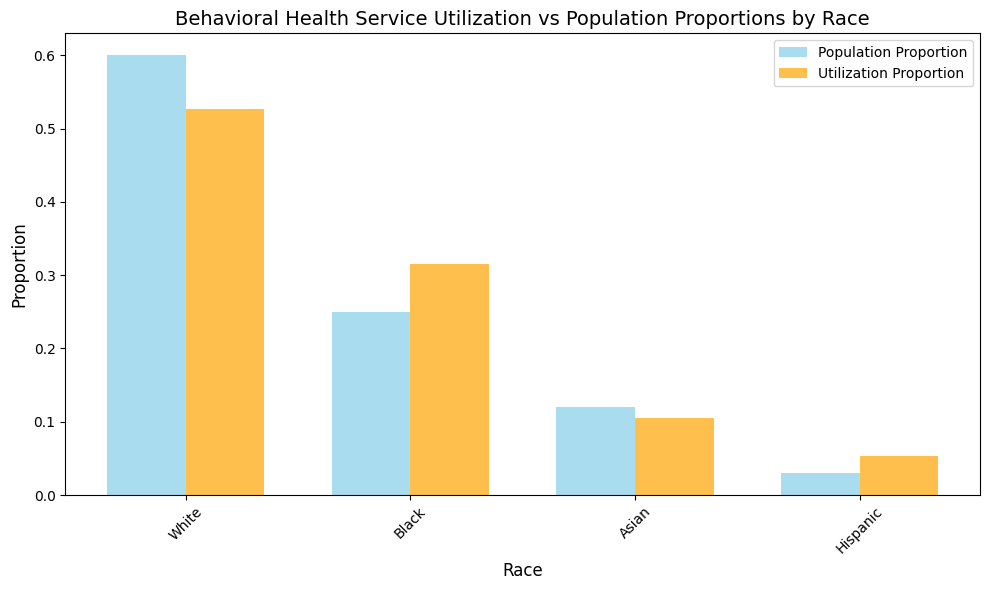

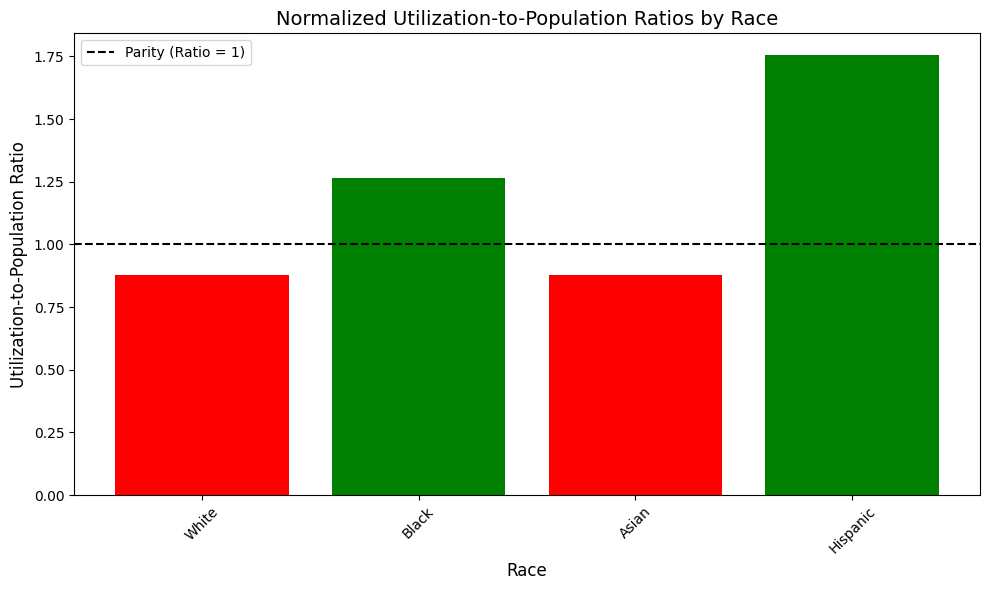


Summary of Underrepresentation Analysis:
- White is underrepresented (Ratio: 0.88). Potential barriers may include:
  - Language barriers
  - Cultural stigmas around mental health
  - Lack of service availability in certain regions
  - Other socioeconomic factors
- Black is adequately represented (Ratio: 1.26).
- Asian is underrepresented (Ratio: 0.88). Potential barriers may include:
  - Language barriers
  - Cultural stigmas around mental health
  - Lack of service availability in certain regions
  - Other socioeconomic factors
- Hispanic is adequately represented (Ratio: 1.75).

Recommendations for Addressing Underrepresentation:
- Implement targeted awareness campaigns for underrepresented groups.
- Hire multilingual staff to address language barriers.
- Develop culturally sensitive programs to reduce stigma.
- Improve accessibility of behavioral health services in underserved regions.


In [ ]:
#Code Snippet #2
import pandas as pd
import matplotlib.pyplot as plt


try:
    # Update these paths to your actual file locations
    utilization_data = pd.read_csv("utilization_race_group.csv")
    demographics_data = pd.read_csv("demographics_race_group.csv")
except FileNotFoundError:
    print("File not found. Using sample data for testing...")
    # Sample utilization data
    utilization_data = pd.DataFrame({
        "race": ["White", "Black", "Asian", "Hispanic"],
        "service_users": [5000, 3000, 1000, 500]
    })

    # Sample demographics data
    demographics_data = pd.DataFrame({
        "race": ["White", "Black", "Asian", "Hispanic"],
        "population": [6000, 2500, 1200, 300]
    })

# Continue with the analysis as before...


# Preview datasets
print("Utilization Data Preview:")
print(utilization_data.head())
print("\nDemographics Data Preview:")
print(demographics_data.head())

# Ensure column names are standardized for merging and calculations
utilization_data.columns = [col.strip().lower().replace(" ", "_") for col in utilization_data.columns]
demographics_data.columns = [col.strip().lower().replace(" ", "_") for col in demographics_data.columns]

# Step 1: Calculate service utilization proportions by race
# Assuming columns: 'race' and 'service_users' in utilization_data
utilization_totals = utilization_data['service_users'].sum()
utilization_data['utilization_proportion'] = utilization_data['service_users'] / utilization_totals

# Step 2: Calculate population proportions by race
# Assuming columns: 'race' and 'population' in demographics_data
population_totals = demographics_data['population'].sum()
demographics_data['population_proportion'] = demographics_data['population'] / population_totals

# Step 3: Merge datasets to compare proportions
merged_data = pd.merge(utilization_data, demographics_data, on='race', how='inner')

# Step 4: Normalize utilization rates
# Compute ratio of service utilization to population for each race group
merged_data['utilization_to_population_ratio'] = merged_data['utilization_proportion'] / merged_data['population_proportion']

# Step 5: Identify underrepresentation
# Ratios below 1 indicate underrepresentation
merged_data['underrepresented'] = merged_data['utilization_to_population_ratio'] < 1

# Display merged data
print("\nMerged Data with Calculations:")
print(merged_data[['race', 'utilization_proportion', 'population_proportion', 'utilization_to_population_ratio', 'underrepresented']])

# Step 6: Visualization
# Bar plot for utilization vs population proportions
plt.figure(figsize=(10, 6))
bar_width = 0.35
races = merged_data['race']
x = range(len(races))

# Plot population proportions
plt.bar(x, merged_data['population_proportion'], width=bar_width, label='Population Proportion', alpha=0.7, color='skyblue')

# Plot utilization proportions
plt.bar([i + bar_width for i in x], merged_data['utilization_proportion'], width=bar_width, label='Utilization Proportion', alpha=0.7, color='orange')

# Add labels and legend
plt.title("Behavioral Health Service Utilization vs Population Proportions by Race", fontsize=14)
plt.xlabel("Race", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.xticks([i + bar_width / 2 for i in x], races, rotation=45, fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

# Bar plot for utilization-to-population ratios
plt.figure(figsize=(10, 6))
plt.bar(races, merged_data['utilization_to_population_ratio'], color=['green' if x >= 1 else 'red' for x in merged_data['utilization_to_population_ratio']])
plt.axhline(1, color='black', linestyle='--', label='Parity (Ratio = 1)')
plt.title("Normalized Utilization-to-Population Ratios by Race", fontsize=14)
plt.xlabel("Race", fontsize=12)
plt.ylabel("Utilization-to-Population Ratio", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

# Step 7: Hypothesize Barriers and Recommendations (Print Summary)
print("\nSummary of Underrepresentation Analysis:")
for _, row in merged_data.iterrows():
    if row['underrepresented']:
        print(f"- {row['race']} is underrepresented (Ratio: {row['utilization_to_population_ratio']:.2f}). Potential barriers may include:")
        print("  - Language barriers")
        print("  - Cultural stigmas around mental health")
        print("  - Lack of service availability in certain regions")
        print("  - Other socioeconomic factors")
    else:
        print(f"- {row['race']} is adequately represented (Ratio: {row['utilization_to_population_ratio']:.2f}).")

# Policy and Outreach Recommendations
print("\nRecommendations for Addressing Underrepresentation:")
print("- Implement targeted awareness campaigns for underrepresented groups.")
print("- Hire multilingual staff to address language barriers.")
print("- Develop culturally sensitive programs to reduce stigma.")
print("- Improve accessibility of behavioral health services in underserved regions.")


Total Service Utilization by Gender:
gender
Female    170
Male      270
Name: count, dtype: int64


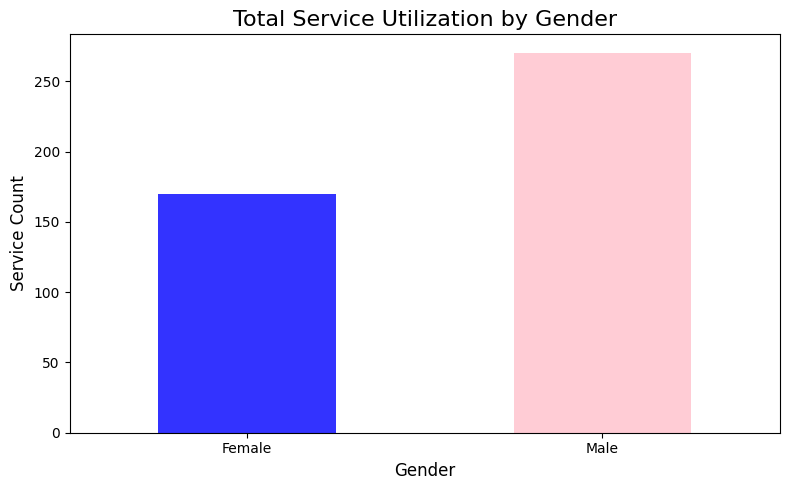

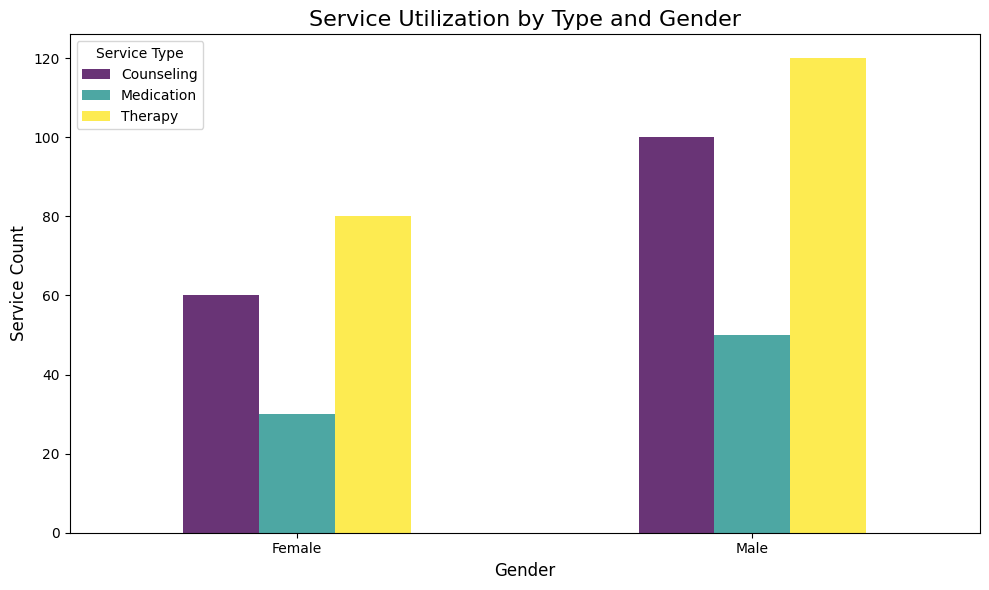

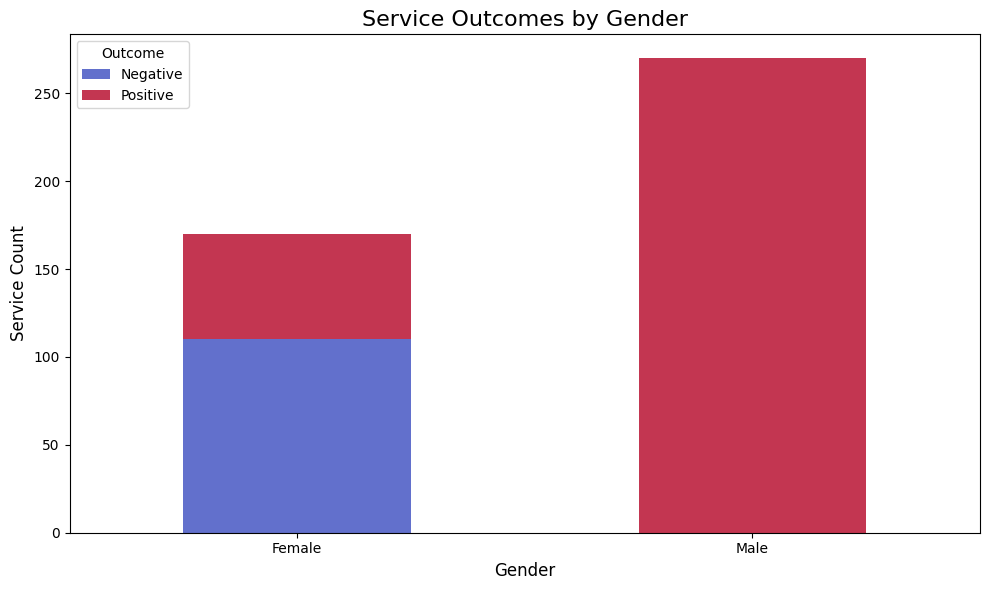


Service Type Utilization Percentage by Gender:
service_type  Counseling  Medication    Therapy
gender                                         
Female         35.294118   17.647059  47.058824
Male           37.037037   18.518519  44.444444

Service Outcome Percentage by Gender:
outcome   Negative    Positive
gender                        
Female   64.705882   35.294118
Male           NaN  100.000000


In [ ]:
#Code Snippet #3
import pandas as pd
import matplotlib.pyplot as plt

# Example datasets (replace these with your actual datasets)
# Assuming `utilization_gender_services` has columns: 'gender', 'service_type', 'outcome', 'count'
# gender: 'Male', 'Female'; service_type: types of services (e.g., 'therapy', 'counseling'); outcome: 'Positive', 'Negative'; count: number of cases
data = {
    'gender': ['Male', 'Male', 'Female', 'Female', 'Male', 'Female'],
    'service_type': ['Therapy', 'Counseling', 'Therapy', 'Counseling', 'Medication', 'Medication'],
    'outcome': ['Positive', 'Positive', 'Negative', 'Positive', 'Positive', 'Negative'],
    'count': [120, 100, 80, 60, 50, 30]
}

df = pd.DataFrame(data)

# 1. Gender-Based Total Service Utilization
gender_totals = df.groupby('gender')['count'].sum()
print("Total Service Utilization by Gender:")
print(gender_totals)

# Plot Total Service Utilization by Gender
plt.figure(figsize=(8, 5))
gender_totals.plot(kind='bar', color=['blue', 'pink'], alpha=0.8)
plt.title("Total Service Utilization by Gender", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Service Count", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Service Types Utilization by Gender
service_by_gender = df.groupby(['gender', 'service_type'])['count'].sum().unstack()

# Plot Service Types Utilization by Gender
service_by_gender.plot(kind='bar', figsize=(10, 6), alpha=0.8, cmap='viridis')
plt.title("Service Utilization by Type and Gender", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Service Count", fontsize=12)
plt.legend(title="Service Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Outcomes Analysis by Gender
outcomes_by_gender = df.groupby(['gender', 'outcome'])['count'].sum().unstack()

# Plot Outcomes Analysis by Gender
outcomes_by_gender.plot(kind='bar', figsize=(10, 6), stacked=True, alpha=0.8, cmap='coolwarm')
plt.title("Service Outcomes by Gender", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Service Count", fontsize=12)
plt.legend(title="Outcome")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Deeper Dive: Percentage Analysis
# Gender-specific percentage utilization for each service type
service_percentage = service_by_gender.div(service_by_gender.sum(axis=1), axis=0) * 100
print("\nService Type Utilization Percentage by Gender:")
print(service_percentage)

# Gender-specific percentage outcomes
outcome_percentage = outcomes_by_gender.div(outcomes_by_gender.sum(axis=1), axis=0) * 100
print("\nService Outcome Percentage by Gender:")
print(outcome_percentage)


In [ ]:
#Code Snippet #4
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# List all files in the working directory (if already uploaded to Colab)
print("Files in the working directory:")
files = os.listdir()
print(files)

# Dictionary to map specific file names to descriptive dataset names
file_mapping = {
    "children-and-youth-mental-health-services-utilization-by-age-group.csv": "utilization_age_group",
    "children-and-youth-snapshot-report-by-age-group.csv": "snapshot_report_age_group",  # Adding related files
    "children-and-youth-time-to-step-down-by-age-group.csv": "time_to_step_down_age_group"
}

# Create an empty dictionary to store loaded DataFrames
datasets = {}

# Load each file into a DataFrame and assign to the datasets dictionary
for file in files:
    if file in file_mapping.keys():
        dataset_name = file_mapping[file]
        if file.endswith('.csv'):
            datasets[dataset_name] = pd.read_csv(file)
            print(f"Loaded {dataset_name} successfully!")
        elif file.endswith('.json'):
            import json
            with open(file) as f:
                datasets[dataset_name] = json.load(f)
                print(f"Loaded {dataset_name} (JSON) successfully!")

# Display the first few rows of each dataset to confirm loading
for name, df in datasets.items():
    if isinstance(df, pd.DataFrame):
        print(f"\nPreview of {name}:")
        print(df.head())

# Perform cleaning operations on each DataFrame
for name, df in datasets.items():
    if isinstance(df, pd.DataFrame):
        # Fill missing values
        for col in df.columns:
            if df[col].dtype == 'object':  # For categorical columns
                df.loc[:, col] = df[col].fillna(df[col].mode()[0])
            else:  # For numerical columns
                df.loc[:, col] = df[col].fillna(df[col].median())

        # Remove duplicates
        df.drop_duplicates(inplace=True)

        # Rename columns to standardized lowercase format
        df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

        # Save cleaned dataset
        cleaned_file_name = f"{name}_cleaned.csv"
        df.to_csv(cleaned_file_name, index=False)
        print(f"Saved cleaned dataset as {cleaned_file_name}")

# Now, we perform Age Distribution Analysis (Scenario 3)

# Assuming the age group dataset is named 'utilization_age_group' after loading and cleaning
utilization_data = datasets.get('utilization_age_group')

# Step 1: Check if the dataset contains an 'age' or equivalent column
if utilization_data is not None:
    # Print the column names to inspect the data
    print("Columns in 'utilization_age_group':")
    print(utilization_data.columns)

    # Look at the first few rows of the data to understand its structure
    print("\nPreview of the dataset:")
    print(utilization_data.head())

    # Step 2: Adjust the column name if necessary
    # Assuming age-related information is in a column like 'age' or 'age_group'
    if 'age' in utilization_data.columns:
        age_column = 'age'
    elif 'age_group' in utilization_data.columns:
        age_column = 'age_group'
    else:
        print("Error: No age-related column found in the dataset.")
        age_column = None

    # If the age-related column is found, proceed with the analysis
    if age_column:
        # Step 3: Define age groups such as 0-5, 6-12, 13-18 years
        age_bins = [0, 5, 12, 18]  # Age groups: 0-5, 6-12, 13-18
        age_labels = ['0-5', '6-12', '13-18']

        # Group users by the age column
        utilization_data['age_group'] = pd.cut(utilization_data[age_column], bins=age_bins, labels=age_labels, right=True)

        # Step 4: Count the number of users in each age group
        age_group_counts = utilization_data['age_group'].value_counts().sort_index()

        # Step 5: Visualize the age distribution
        sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis')
        plt.title('Age Distribution of Service Users')
        plt.xlabel('Age Group')
        plt.ylabel('Number of Service Users')
        plt.show()

else:
    print("Error: 'utilization_age_group' dataset not found.")


Files in the working directory:
['.config', 'children-and-youth-mental-health-services-utilization-by-race-group.csv', 'children-and-youth-time-to-step-down-by-sex.csv', 'time_to_step_down_written_language_cleaned.csv', 'demographics_race_group_cleaned.csv', 'statewide-top-10-icd10-diagnosis-code-categories-for-children-and-youth-by-race-group.csv', 'icd10_diagnosis_race_group_cleaned.csv', 'children-and-youth-demographics-by-race-group.csv', 'snapshot_report_age_group_cleaned.csv', 'icd10_diagnosis_age_group_cleaned.csv', 'icd10_diagnosis_sex_cleaned.csv', 'children-and-youth-time-to-step-down-by-written-language.csv', 'utilization_sex_cleaned.csv', 'statewide-top-10-icd10-diagnosis-code-categories-for-children-and-youth-by-sex.csv', 'children-and-youth-snapshot-by-written-language.csv', 'datapackage.json', 'utilization_age_group_cleaned.csv', 'utilization_written_language_cleaned.csv', 'children-and-youth-mental-health-services-utilization-by-sex.csv', 'demographics_sex_cleaned.csv',

In [ ]:
#Code Snippet #5
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define the file path for the dataset (it's the same file, just mentioned twice)
file_path = '/content/time_to_step_down_race_group_cleaned.csv'

# Load the dataset
try:
    time_to_step_down_df = pd.read_csv(file_path)
    print(f"Loaded {os.path.basename(file_path)} successfully!")
except Exception as e:
    print(f"Error loading {file_path}: {e}")

# Inspect the first few rows of the dataset to understand its structure
print("\nPreview of time_to_step_down_race_group_cleaned dataset:")
print(time_to_step_down_df.head())

# Now, let's visualize the distribution of service users by race group
def plot_demographic_distribution(df, group_by_column, title):
    if group_by_column in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(x=group_by_column, data=df, palette='viridis')
        plt.title(title)
        plt.xlabel(group_by_column)
        plt.ylabel('Number of Service Users')
        plt.show()
    else:
        print(f"Column '{group_by_column}' not found in the dataset.")

# Visualize the distribution of service users by race group
plot_demographic_distribution(time_to_step_down_df, 'race_group', 'Race Group Distribution for Time to Step Down')


Loaded time_to_step_down_race_group_cleaned.csv successfully!

Preview of time_to_step_down_race_group_cleaned dataset:
  population_name population_type  fiscal_year  \
0         Alameda               1         2019   
1         Alameda               1         2019   
2         Alameda               1         2019   
3         Alameda               1         2019   
4         Alameda               1         2019   

                               race_grp  less7_ct  less7_ct_annot  \
0  R1 Alaskan Native or American Indian      27.0             1.0   
1          R2 Asian or Pacific Islander      27.0             1.0   
2                              R3 Black      52.0             1.0   
3                           R4 Hispanic      80.0             1.0   
4                              R5 White      38.0             1.0   

   between_8and30_ct  between_8and30_ct_annot  more30_ct  more30_ct_annot  \
0                0.0                      1.0        0.0              1.0   
1         

In [ ]:
#Code Snippet #6
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
# Assuming the dataset with temporal data includes columns like 'year' or 'month', 'age_group', 'race_group', 'sex', etc.
file_path = '/content/demographics_age_group_cleaned.csv'  # Example dataset path
df = pd.read_csv(file_path)

# Inspect the first few rows of the dataset to check for temporal data
print(df.head())

# Ensure there is a 'year' column or 'month' column to group by
if 'year' in df.columns:
    # Step 1: Group users by year and count the number of service users in each year
    yearly_data = df.groupby('year').size().reset_index(name='user_count')

    # Step 2: Visualize the number of users over the years
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='year', y='user_count', data=yearly_data, marker='o')
    plt.title('Service Users Over Time (by Year)')
    plt.xlabel('Year')
    plt.ylabel('Number of Service Users')
    plt.grid(True)
    plt.show()

    # Step 3: Analyze shifts in demographic characteristics over time
    # 3.1: Age group distribution over the years
    age_group_trends = df.groupby(['year', 'age_group']).size().unstack().fillna(0)
    age_group_trends.plot(kind='line', figsize=(12, 6), marker='o')
    plt.title('Age Group Distribution Over Time')
    plt.xlabel('Year')
    plt.ylabel('Number of Users')
    plt.grid(True)
    plt.show()

    # 3.2: Ethnicity distribution over the years
    ethnicity_trends = df.groupby(['year', 'race_group']).size().unstack().fillna(0)
    ethnicity_trends.plot(kind='line', figsize=(12, 6), marker='o')
    plt.title('Ethnicity Distribution Over Time')
    plt.xlabel('Year')
    plt.ylabel('Number of Users')
    plt.grid(True)
    plt.show()

    # 3.3: Gender distribution over the years
    gender_trends = df.groupby(['year', 'sex']).size().unstack().fillna(0)
    gender_trends.plot(kind='line', figsize=(12, 6), marker='o')
    plt.title('Gender Distribution Over Time')
    plt.xlabel('Year')
    plt.ylabel('Number of Users')
    plt.grid(True)
    plt.show()



  population_name population_type  fiscal_year            age_grp  total_ct  \
0         Alameda               1         2019    A1 Children 0-2   23982.0   
1         Alameda               1         2019    A2 Children 3-5   24483.0   
2         Alameda               1         2019   A3 Children 6-11   49968.0   
3         Alameda               1         2019  A4 Children 12-17   48634.0   
4         Alameda               1         2019     A5 Youth 18-20   22169.0   

   total_ct_annot  mhs1_ct  mhs1_ct_annot  mhs5_ct  mhs5_ct_annot  \
0             1.0   2647.0            1.0     35.0            1.0   
1             1.0   1605.0            1.0    423.0            1.0   
2             1.0   3675.0            1.0    912.0            1.0   
3             1.0   5891.0            1.0   1056.0            1.0   
4             1.0   1856.0            1.0    337.0            1.0   

  medi_cal_delivery_system  
0                      MHS  
1                      MHS  
2                      

In [ ]:
#Code Snippet #7
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load datasets
datasets = {}
file_mapping = {
    "children-and-youth-demographics-by-age-group.csv": "demographics_age_group",
    "children-and-youth-demographics-by-race-group.csv": "demographics_race_group"
}

# Load all datasets into a dictionary
for file in os.listdir():
    for key, value in file_mapping.items():
        if file == key:
            try:
                datasets[value] = pd.read_csv(file)
                print(f"Loaded {value} successfully!")
            except Exception as e:
                print(f"Error loading {file}: {e}")

# Check dataset structure
for name, df in datasets.items():
    print(f"{name} dataset preview:")
    print(df.head())

# Merge datasets for cross-tabulation
if 'demographics_age_group' in datasets and 'demographics_race_group' in datasets:
    demographics_age_group_df = datasets['demographics_age_group']
    demographics_race_group_df = datasets['demographics_race_group']

    # Adjust merge logic if necessary
    merged_df = pd.concat([demographics_age_group_df, demographics_race_group_df], axis=1)
    print(f"Merged dataset shape: {merged_df.shape}")
    print(merged_df.head())

    # Perform cross-tabulation
    if 'age_group' in merged_df.columns and 'race_group' in merged_df.columns:
        cross_tab_result = pd.crosstab(merged_df['age_group'], merged_df['race_group'], margins=True)
        print("Cross-tabulation result:")
        print(cross_tab_result)

        # Plot heatmap
        if not cross_tab_result.empty:
            plt.figure(figsize=(12, 8))
            sns.heatmap(cross_tab_result.iloc[:-1, :-1], annot=True, fmt="d", cmap="YlGnBu", cbar=True)
            plt.title("Cross-Tabulation: Age Group vs Race Group")
            plt.xlabel("Race Group")
            plt.ylabel("Age Group")
            plt.xticks(rotation=45)
            plt.show()
        else:
            print("Cross-tabulation result is empty. No heatmap generated.")
else:
    print("Required datasets for cross-tabulation are not available.")


Loaded demographics_race_group successfully!
Loaded demographics_age_group successfully!
demographics_race_group dataset preview:
  POPULATION_NAME POPULATION_TYPE  FISCAL_YEAR  \
0         Alameda               1         2019   
1         Alameda               1         2019   
2         Alameda               1         2019   
3         Alameda               1         2019   
4         Alameda               1         2019   

                               RACE_GRP  TOTAL_CT  TOTAL_CT_ANNOT  MHS1_CT  \
0  R1 Alaskan Native or American Indian     352.0             NaN     43.0   
1          R2 Asian or Pacific Islander   27300.0             NaN   1865.0   
2                              R3 Black   28112.0             NaN   2901.0   
3                           R4 Hispanic   71054.0             NaN   6588.0   
4                              R5 White   11380.0             NaN   1481.0   

   MHS1_CT_ANNOT  MHS5_CT  MHS5_CT_ANNOT MEDI_CAL_DELIVERY_SYSTEM  
0            NaN     12.0       

Loaded utilization_age_group successfully!
Loaded demographics_age_group successfully!
Socioeconomic data not found. Skipping socioeconomic analysis...
Demographics Dataset Columns: Index(['POPULATION_NAME', 'POPULATION_TYPE', 'FISCAL_YEAR', 'AGE_GRP',
       'TOTAL_CT', 'TOTAL_CT_ANNOT', 'MHS1_CT', 'MHS1_CT_ANNOT', 'MHS5_CT',
       'MHS5_CT_ANNOT', 'MEDI_CAL_DELIVERY_SYSTEM'],
      dtype='object')
Utilization Dataset Columns: Index(['POPULATION_NAME', 'POPULATION_TYPE', 'FISCAL_YEAR', 'AGE_GRP',
       'SVC_DESC', 'UNIT_TYPE', 'AMOUNT', 'AMOUNT_ANNOT',
       'MEDI_CAL_DELIVERY_SYSTEM'],
      dtype='object')
Socioeconomic data not found. Skipping socioeconomic analysis...
Common columns for merging: ['FISCAL_YEAR', 'POPULATION_NAME', 'POPULATION_TYPE', 'AGE_GRP', 'MEDI_CAL_DELIVERY_SYSTEM']
Merged dataset shape: (329271, 15)
  POPULATION_NAME POPULATION_TYPE  FISCAL_YEAR          AGE_GRP  TOTAL_CT  \
0         Alameda               1         2019  A1 Children 0-2   23982.0   
1    

<ipython-input-7-17fdaf0409d5>:78: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df["TOTAL_CT"].fillna(merged_df["TOTAL_CT"].median(), inplace=True)
<ipython-input-7-17fdaf0409d5>:79: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

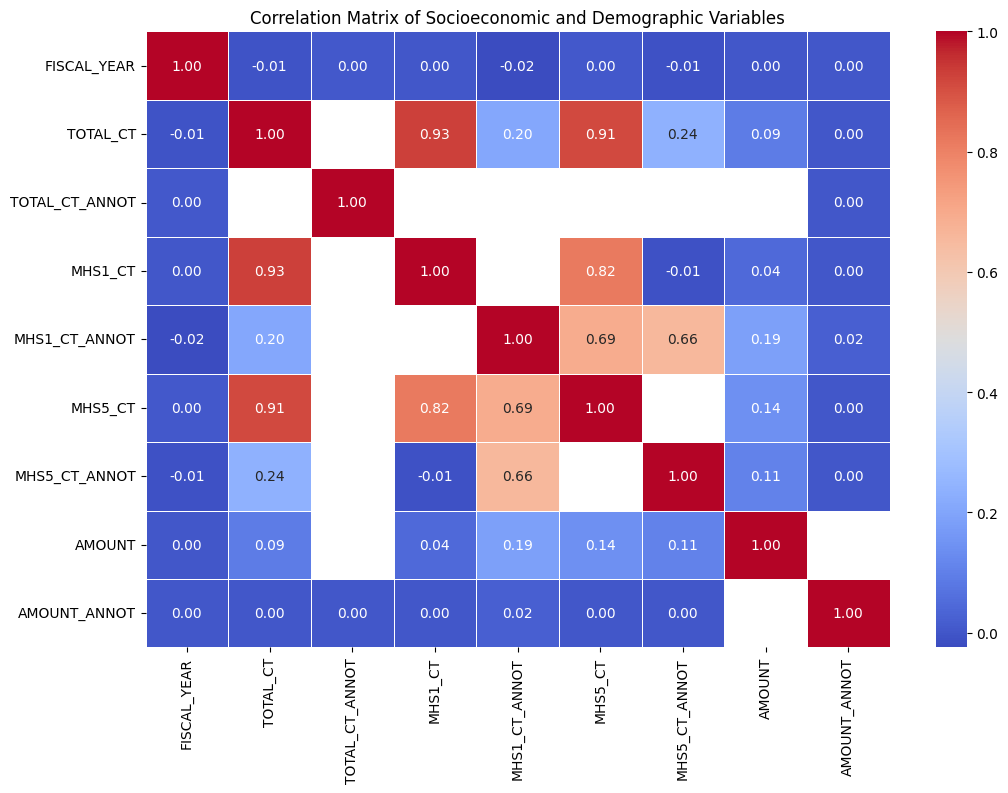

Columns 'income_level' or 'AMOUNT' are not found in the merged dataset.
Columns 'written_language' or 'AMOUNT' are not found in the merged dataset.


In [ ]:
#Code Snippet #8
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway
import os

# Create an empty dictionary to store loaded DataFrames
datasets = {}  # Define datasets here

# Load datasets (ensure this code is executed before accessing 'datasets')
file_mapping = {
    "children-and-youth-demographics-by-age-group.csv": "demographics_age_group",
    "children-and-youth-mental-health-services-utilization-by-age-group.csv": "utilization_age_group"
    # ... add other file mappings as needed
}

for file in os.listdir():
    for key, value in file_mapping.items():
        if file == key:
            try:
                datasets[value] = pd.read_csv(file)
                print(f"Loaded {value} successfully!")
            except Exception as e:
                print(f"Error loading {file}: {e}")

# Now you can access 'datasets' in the rest of your code
# ... (rest of your code)
# Check if socioeconomic data is available
if "socioeconomic_data" not in datasets:
    print("Socioeconomic data not found. Skipping socioeconomic analysis...")
    socioeconomic_df = None  # Explicitly set to None if not using socioeconomic data
else:
    socioeconomic_df = datasets.get("socioeconomic_data")  # Replace with the correct key if necessary
# ... (previous code) ...

# Accessing the demographics dataframe from the 'datasets' dictionary
demographics_df = datasets.get("demographics_age_group")
utilization_df = datasets.get("utilization_age_group")

# ... (rest of your code) ...
# Step 1: Inspect the datasets
print("Demographics Dataset Columns:", demographics_df.columns)
print("Utilization Dataset Columns:", utilization_df.columns)

# Check if socioeconomic data is available before printing columns
if socioeconomic_df is not None:
    print("Socioeconomic Dataset Columns:", socioeconomic_df.columns)
else:
    print("Socioeconomic data not found. Skipping socioeconomic analysis...")

# Step 2: Merge datasets
# Merge on a common key, such as 'population_name'. Replace 'user_id' with the correct column for merging
if demographics_df is not None and utilization_df is not None:
    # Identify common columns for merging
    common_cols = list(set(demographics_df.columns) & set(utilization_df.columns))
    print(f"Common columns for merging: {common_cols}")
    # Assuming 'population_type', 'age_group', 'ethnicity', 'sex', 'written_language' are common identifiers
    # Adjust the 'on' parameter with the actual common columns
    merged_df = pd.merge(demographics_df, utilization_df, how="inner", on=common_cols)
    if socioeconomic_df is not None:
        # If socioeconomic_df has the same common identifiers, you can merge it as well
        merged_df = pd.merge(merged_df, socioeconomic_df, how="inner", on=common_cols)
    print(f"Merged dataset shape: {merged_df.shape}")
    print(merged_df.head())
else:
    print("Missing one of the required datasets for merging.")

# Step 3: Data Cleaning and Validation
# Check for missing values
missing_values = merged_df.isnull().sum()
print("Missing values in merged dataset:")
print(missing_values)

# Option 1: Drop rows with missing values (or choose specific columns to dropna)
# merged_df.dropna(subset=["column_of_interest"], inplace=True)

# Option 2: Impute missing values (you can fill with median, mean, or other strategies based on your data)
merged_df["TOTAL_CT"].fillna(merged_df["TOTAL_CT"].median(), inplace=True)
merged_df["MHS1_CT"].fillna(merged_df["MHS1_CT"].median(), inplace=True)
merged_df["AMOUNT"].fillna(merged_df["AMOUNT"].median(), inplace=True)

# Step 4: Correlation Analysis
# Select numeric columns for correlation matrix
numeric_cols = merged_df.select_dtypes(include=["float64", "int64"]).columns
correlation_matrix = merged_df[numeric_cols].corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Socioeconomic and Demographic Variables")
plt.show()

# Step 5: Analyze Service Utilization by Income Level (check if columns exist)
if "income_level" in merged_df.columns and "AMOUNT" in merged_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="income_level", y="AMOUNT", data=merged_df, palette="Set3")
    plt.title("Service Utilization by Income Level")
    plt.xlabel("Income Level")
    plt.ylabel("Service Utilization (AMOUNT)")
    plt.show()
else:
    print("Columns 'income_level' or 'AMOUNT' are not found in the merged dataset.")

# Step 6: Demographics Analysis (e.g., Race and Income Level)
if "race_group" in merged_df.columns and "income_level" in merged_df.columns:
    race_income_ct = pd.crosstab(merged_df["race_group"], merged_df["income_level"])
    print("\nRace Group vs Income Level Cross-Tabulation:")
    print(race_income_ct)

    # Visualize with a heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(race_income_ct, annot=True, fmt="d", cmap="Blues")
    plt.title("Cross-Tabulation: Race Group vs Income Level")
    plt.xlabel("Income Level")
    plt.ylabel("Race Group")
    plt.show()

# Step 7: Hypothesis Testing
# Chi-square test: Relationship between Race Group and Income Level
if "race_group" in merged_df.columns and "income_level" in merged_df.columns:
    chi2, p, dof, expected = chi2_contingency(race_income_ct)
    print(f"\nChi-square Test Results:\nChi2 = {chi2:.2f}, p-value = {p:.4f}, Degrees of Freedom = {dof}")

# ANOVA: Service Utilization across Income Levels
if "income_level" in merged_df.columns and "AMOUNT" in merged_df.columns:
    income_groups = merged_df["income_level"].unique()
    utilization_groups = [
        merged_df.loc[merged_df["income_level"] == group, "AMOUNT"]
        for group in income_groups
    ]
    f_stat, p_value = f_oneway(*utilization_groups)
    print(f"\nANOVA Test Results:\nF-statistic = {f_stat:.2f}, p-value = {p_value:.4f}")

# Step 8: Insights on Socioeconomic Barriers (Explore if relevant columns exist)
if "written_language" in merged_df.columns and "AMOUNT" in merged_df.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(x="written_language", y="AMOUNT", data=merged_df, palette="viridis", ci=None)
    plt.title("Service Utilization by Written Language")
    plt.xlabel("Written Language")
    plt.ylabel("Average Service Utilization (AMOUNT)")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Columns 'written_language' or 'AMOUNT' are not found in the merged dataset.")
